# `Industrial Machine Learning on Hadoop and Spark`
## `Task 03: Spark Basics + EDA + ML`

### `Maks Nakhodnov`
#### `Bremen, 2025`

<span style="color:red">Deadline: December 08, 2025. 23:59</span>

In [ ]:
! pip3 install pyspark pyarrow pyspark_dist_explore wget seaborn -q

In [ ]:
import os
import datetime
from typing import List, Optional

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['figure.dpi'] = 300

import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
%matplotlib inline

In [3]:

import pyspark
import pyspark.sql.types as T
import pyspark.sql.functions as F
from pyspark.sql.window import Window

import pyspark_dist_explore

from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext

conf = (
    SparkConf()
        .set('spark.ui.port', '4050')
        .set('spark.driver.memory', '6g')
        .setMaster('local[*]')
)
sc = SparkContext(conf=conf)
spark = SparkSession(sc)

25/11/30 23:54:01 WARN Utils: Your hostname, DESKTOP-8FB26C5 resolves to a loopback address: 127.0.1.1; using 172.29.27.85 instead (on interface eth0)
25/11/30 23:54:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/30 23:54:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### `Part 1`

#### `1.1. Spark Basics`

Download and unpack the data:

In [4]:
import wget
import zipfile

filename = wget.download(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
)
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall('./smsspamcollection')

**Task 1.1:** Read the data into DataFrame:

In [ ]:
### 1.1 YOUR CODE HERE
spam_df = ...
spam_df

DataFrame[_c0: string, _c1: string]

**Task 1.2:** Name the table columns `class` and `text`:

In [ ]:
### 1.2 YOUR CODE HERE
spam_df = ...
spam_df

DataFrame[class: string, text: string]

**Task 1.3:** Output the first $3$ rows of the dataset:

In [ ]:
### 1.3 YOUR CODE HERE
...

+-----+--------------------+
|class|                text|
+-----+--------------------+
|  ham|Go until jurong p...|
|  ham|Ok lar... Joking ...|
| spam|Free entry in 2 a...|
+-----+--------------------+
only showing top 3 rows



**Task 1.4:** Create two new columns: `words` — a list of words in the text, and `length` — the length of this list. Implement the request in a single statement:

In [ ]:
### 1.4 YOUR CODE HERE
spam_df = ...
spam_df.show(3)

+-----+--------------------+--------------------+------+
|class|                text|               words|length|
+-----+--------------------+--------------------+------+
|  ham|Go until jurong p...|[Go, until, juron...|    20|
|  ham|Ok lar... Joking ...|[Ok, lar..., Joki...|     6|
| spam|Free entry in 2 a...|[Free, entry, in,...|    28|
+-----+--------------------+--------------------+------+
only showing top 3 rows



**Task 1.5:** Calculate the average text length depending on the class:

In [ ]:
### 1.5 YOUR CODE HERE
...

+--------------------+------------------+
|               class|       mean_length|
+--------------------+------------------+
|                 ham|14.427594779366066|
|                spam| 23.95314591700134|
|We would apprecia...|              -1.0|
|spam   URGENT! Yo...|              -1.0|
|1. Tiago Agostinh...|              -1.0|
|3. Limitation of ...|              -1.0|
|ham   Cos i was o...|              -1.0|
|    1.1. Compilation|              -1.0|
|      1. DESCRIPTION|              -1.0|
|The SMS Spam Coll...|              -1.0|
|Note: messages ar...|              -1.0|
|We offer a compre...|              -1.0|
|-----------------...|              -1.0|
|         1.3. Format|              -1.0|
|            --------|              -1.0|
|- A collection of...|              -1.0|
|The files contain...|              -1.0|
|The corpus has be...|              -1.0|
|2. No Warranty/Us...|              -1.0|
|ham   Siva is in ...|              -1.0|
+--------------------+------------

**Task 1.6:** Output approximately $0.1\%$ of the longest texts:

In [ ]:
### 1.6 YOUR CODE HERE
quantile = ...
...

+-----+--------------------+--------------------+------+
|class|                text|               words|length|
+-----+--------------------+--------------------+------+
|  ham|For me the love s...|[For, me, the, lo...|   171|
|  ham|How to Make a gir...|[How, to, Make, a...|   121|
|  ham|The last thing i ...|[The, last, thing...|   162|
|  ham|Sad story of a Ma...|[Sad, story, of, ...|   125|
|  ham|Good evening Sir,...|[Good, evening, S...|    99|
|  ham|Indians r poor bu...|[Indians, r, poor...|   119|
|  ham|Sad story of a Ma...|[Sad, story, of, ...|   125|
+-----+--------------------+--------------------+------+



**Task 1.7:** Find the $10$ words with the highest Document Frequency (number of SMS messages in which the word appears at least once):

In [ ]:
### 1.7 YOUR CODE HERE
counts_df = ...
counts_df.show(10)

+----+-----+
|word|count|
+----+-----+
|  to| 1635|
| you| 1220|
|   I| 1128|
|   a| 1103|
| the|  967|
|  in|  725|
| and|  704|
|  is|  662|
|   i|  592|
| for|  575|
+----+-----+
only showing top 10 rows



**Task 1.8:** Assume two matrices $A$ and $B$ are given in coordinate format. Implement matrix multiplication:

In [ ]:
# 4 x 3
A_data = [
    (0, 0, 8), (0, 1, 5), (0, 2, 8),
    (1, 0, 2), (1, 1, 5), (1, 2, 6),
    (2, 0, 2), (2, 1, 6), (2, 2, 4),
    (3, 0, 6), (3, 1, 3), (3, 2, 3),
]

# 3 x 5
B_data = [
    (0, 0, 9), (0, 1, 4), (0, 2, 9), (0, 3, 9), (0, 4, 1),
    (1, 0, 2), (1, 1, 5), (1, 2, 7), (1, 3, 3), (1, 4, 0),
    (2, 0, 9), (2, 1, 5), (2, 2, 7), (2, 3, 9), (2, 4, 0),
]

A = spark.createDataFrame(A_data, schema=['i', 'j', 'v'])
B = spark.createDataFrame(B_data, schema=['i', 'j', 'v'])

### 1.8 YOUR CODE HERE
C = ...
C.show()

+---+---+---+
|  i|  j|  v|
+---+---+---+
|  0|  0|154|
|  0|  1| 97|
|  0|  2|163|
|  0|  3|159|
|  0|  4|  8|
|  1|  0| 82|
|  1|  1| 63|
|  1|  2| 95|
|  1|  3| 87|
|  1|  4|  2|
|  2|  0| 66|
|  2|  1| 58|
|  2|  2| 88|
|  2|  3| 72|
|  2|  4|  2|
|  3|  0| 87|
|  3|  1| 54|
|  3|  2| 96|
|  3|  3| 90|
|  3|  4|  6|
+---+---+---+



**Task 1.9**: Implement the multiplication of the same matrices as in Task 8, but using `spark.sql`:

In [ ]:
### 1.9 YOUR CODE HERE
...

spark.sql('''
    ...
''').show()

+---+---+---+
|  i|  j|  v|
+---+---+---+
|  0|  0|154|
|  0|  1| 97|
|  0|  2|163|
|  0|  3|159|
|  0|  4|  8|
|  1|  0| 82|
|  1|  1| 63|
|  1|  2| 95|
|  1|  3| 87|
|  1|  4|  2|
|  2|  0| 66|
|  2|  1| 58|
|  2|  2| 88|
|  2|  3| 72|
|  2|  4|  2|
|  3|  0| 87|
|  3|  1| 54|
|  3|  2| 96|
|  3|  3| 90|
|  3|  4|  6|
+---+---+---+



#### `1.2. Merging `$n$` sorted arrays`

It is known that the most computationally expensive operation is distributed sorting during Shuffle/Wide transformations. Let's discuss how to implement it efficiently.

In the first step, sorted data is generated locally to the source data, pre-partitioned for the future reducers/workers of the next stage. This data is already sorted in memory before being transferred between nodes. Each destination node will receive lists of sorted data, which must be merged into one large sorted list. How can this be done efficiently?

A well-known algorithm merges two sorted arrays: take one element from both arrays, write the smaller one to the result, and take the next one from the corresponding array.

In [14]:
# Implementation example

x = [1, 2, 5, 10]
y = [3, 4, 6, 12]

def merge(left, right):
    left_iter = iter(left)
    right_iter = iter(right)
    left_elem = next(left_iter, None)
    right_elem = next(right_iter, None)
    result = []
    while left_elem is not None and right_elem is not None:
        if left_elem <= right_elem:
            result.append(left_elem)
            left_elem = next(left_iter, None)            
        else:
            result.append(right_elem)
            right_elem = next(right_iter, None)
    result.append(left_elem or right_elem)
    result.extend(left_iter)
    result.extend(right_iter)
    return result

merge(x, y)

[1, 2, 3, 4, 5, 6, 10, 12]

It relies heavily on the ability to compare two elements. And consequently, it only works for two arrays.

Think about how to generalize this algorithm for the case of `n` sorted arrays?
What will be the algorithmic complexity of the resulting merge algorithm?

Write your answer in the cell below.

[Hint](https://en.wikipedia.org/wiki/Heap_%28data_structure%29)

**Answer:** Your answer here.

#### `1.3. Computational complexity of the external memory sorting algorithm`


A situation often arises where an array needs to be sorted that fits on disk but not in RAM.

Suppose you have:
 * `N` Gb of RAM
 * a processor with very, very many cores, more than you could need
 * an array that weighs `M >> N` Gb
 
Discuss the topic: "What will be the computational complexity of the external memory sorting algorithm in this case?"

**Answer:** Your answer here.

### `Part 2. Spark Details`

Download and unzip data from the [Web Traffic Time Series Forecasting](https://www.kaggle.com/competitions/web-traffic-time-series-forecasting/leaderboard) competition.

In [15]:
! kaggle competitions download -c web-traffic-time-series-forecasting

! unzip web-traffic-time-series-forecasting.zip -d web-traffic-time-series-forecasting
! unzip web-traffic-time-series-forecasting/key_1.csv.zip -d web-traffic-time-series-forecasting
! unzip web-traffic-time-series-forecasting/key_2.csv.zip -d web-traffic-time-series-forecasting
! unzip web-traffic-time-series-forecasting/train_1.csv.zip -d web-traffic-time-series-forecasting
! unzip web-traffic-time-series-forecasting/train_2.csv.zip -d web-traffic-time-series-forecasting
! unzip web-traffic-time-series-forecasting/sample_submission_1.csv.zip -d web-traffic-time-series-forecasting
! unzip web-traffic-time-series-forecasting/sample_submission_2.csv.zip -d web-traffic-time-series-forecasting

! rm -rf web-traffic-time-series-forecasting.zip
! rm -rf web-traffic-time-series-forecasting/sample_submission_1.csv.zip 
! rm -rf web-traffic-time-series-forecasting/sample_submission_2.csv.zip 
! rm -rf web-traffic-time-series-forecasting/key_1.csv.zip web-traffic-time-series-forecasting/key_2.csv.zip
! rm -rf web-traffic-time-series-forecasting/train_1.csv.zip web-traffic-time-series-forecasting/train_2.csv.zip 

100%|████████████████████████████████████████▉| 582M/583M [00:02<00:00, 223MB/s]
100%|█████████████████████████████████████████| 583M/583M [00:02<00:00, 223MB/s]
Archive:  web-traffic-time-series-forecasting.zip
  inflating: web-traffic-time-series-forecasting/key_1.csv.zip  
  inflating: web-traffic-time-series-forecasting/key_2.csv.zip  
  inflating: web-traffic-time-series-forecasting/sample_submission_1.csv.zip  
  inflating: web-traffic-time-series-forecasting/sample_submission_2.csv.zip  
  inflating: web-traffic-time-series-forecasting/train_1.csv.zip  
  inflating: web-traffic-time-series-forecasting/train_2.csv.zip  
Archive:  web-traffic-time-series-forecasting/key_1.csv.zip
  inflating: web-traffic-time-series-forecasting/key_1.csv  
Archive:  web-traffic-time-series-forecasting/key_2.csv.zip
  inflating: web-traffic-time-series-forecasting/key_2.csv  
Archive:  web-traffic-time-series-forecasting/train_1.csv.zip
  inflating: web-traffic-time-series-forecasting/train_1.csv  

In [16]:
! ls web-traffic-time-series-forecasting

key_1.csv  sample_submission_1.csv  train_1.csv
key_2.csv  sample_submission_2.csv  train_2.csv


Load Wikipedia page view information by day as a DataFrame:

In [17]:
# Construct the DataFrame schema explicitly
# This is necessary for easier filling of missing values
#   as by default all columns with missing values are defined
#   as string
schema = T.StructType()
schema.add('Page', T.StringType())

delta = datetime.timedelta(days=1)
date = datetime.date.fromisoformat('2015-07-01')
for _ in range(803):
    schema.add(date.isoformat(), T.IntegerType())
    date += delta

df = (
    spark.read.format('csv')
        .option('header', True)
        .option('sep', ',')
        .schema(schema)
        .load('./web-traffic-time-series-forecasting/train_2.csv')
        .fillna(0.0)
).cache()

df.limit(5).toPandas()

25/11/30 23:55:42 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2017-09-01,2017-09-02,2017-09-03,2017-09-04,2017-09-05,2017-09-06,2017-09-07,2017-09-08,2017-09-09,2017-09-10
0,2NE1_zh.wikipedia.org_all-access_spider,18,11,5,13,14,9,9,22,26,...,19,33,33,18,16,27,29,23,54,38
1,2PM_zh.wikipedia.org_all-access_spider,11,14,15,18,11,13,22,11,10,...,32,30,11,19,54,25,26,23,13,81
2,3C_zh.wikipedia.org_all-access_spider,1,0,1,1,0,4,0,3,4,...,6,6,7,2,4,7,3,4,7,6
3,4minute_zh.wikipedia.org_all-access_spider,35,13,10,94,4,26,14,9,11,...,7,19,19,9,6,16,19,30,38,4
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0,0,0,0,0,0,0,0,0,...,16,16,19,9,20,23,28,14,8,7


***Note:*** Use the `cache` method to save intermediate results that you plan to reuse!

**Task 2.1:** Split the `Page` column according to the schema in the data description (`name_project_access_agent`). The result should be a DataFrame with $5$ columns: `Page`, `Name`, `Project`, `Access`, `Agent`.

*Note 0*: Do not use UDFs.

*Note 1*: The page name (`Name`) can contain any number of `_` characters.

*Note 2*: Some strings are "wrapped" in double quotes. It is desirable to remove extra outer quotes from all such strings in the first transformation on the `Page` column.

*Note 3:* Rows that do not satisfy the specified pattern need to be isolated in a separate DataFrame.

*Note 4:* For convenience, use the ability to save column expressions into variables.

*Hint 1:* Variable-length substrings can be extracted [as follows](https://stackoverflow.com/questions/53153149/remove-last-few-characters-in-pyspark-dataframe-column).

*Hint 2:* Functions `.when().otherwise()`, `substring`, `size`, `expr`, `split`, `array_join`, `slice`, `element_at` may be useful for solving the problem.

In [ ]:
### 2.1 YOUR CODE HERE:
corrupted_articles = ...
articles = ...

Check that the preprocessing is performed correctly:

In [19]:
corrupted_articles.show(truncate=False)

+---------+
|Page     |
+---------+
|"""Awaken|
|"""Awaken|
|"""Awaken|
+---------+



In [20]:
articles.groupBy('Project').count().show(truncate=False)
articles.groupBy('Access').count().show(truncate=False)
articles.groupBy('Agent').count().show(truncate=False)

+---------------------+-----+
|Project              |count|
+---------------------+-----+
|en.wikipedia.org     |24105|
|zh.wikipedia.org     |17229|
|fr.wikipedia.org     |17802|
|commons.wikimedia.org|10555|
|ru.wikipedia.org     |15022|
|www.mediawiki.org    |7300 |
|de.wikipedia.org     |18547|
|ja.wikipedia.org     |20431|
|es.wikipedia.org     |14069|
+---------------------+-----+

+----------+-----+
|Access    |count|
+----------+-----+
|desktop   |34808|
|all-access|74313|
|mobile-web|35939|
+----------+-----+

+----------+------+
|Agent     |count |
+----------+------+
|all-agents|110148|
|spider    |34912 |
+----------+------+



**Task 2.2:** Perform unpivot of the source data.

*Note 1*: The expression for unpivot needs to be constructed by looping through all columns with dates or by using newer syntax.

*Note 2*: In column string expressions, you can specify columns with arbitrary names using escaping. For example: ``` `2015-07-01` ```.

In [ ]:
date_columns = df.columns[1:]
### 2.2 YOUR CODE HERE:
...
unpivot_df = ...

In [22]:
unpivot_df.show(10, truncate=False)

+---------------------------------------+----------+-----+
|Page                                   |Day       |Views|
+---------------------------------------+----------+-----+
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-01|18   |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-02|11   |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-03|5    |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-04|13   |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-05|14   |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-06|9    |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-07|9    |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-08|22   |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-09|26   |
|2NE1_zh.wikipedia.org_all-access_spider|2015-07-10|24   |
+---------------------------------------+----------+-----+
only showing top 10 rows



**Task 2.3:** For each record in the data, calculate the average number of views for the previous $14$ days.

*Note 1*: Use window functions.

*Note 2*: To work with dates, you can use the `cast` function to convert a string to timestamp.

*Note 3*: Analyze the [answers by `ZygD` and `zero323`](https://stackoverflow.com/questions/33207164/spark-window-functions-rangebetween-dates).

In [ ]:
### 2.3 YOUR CODE HERE:
wspec = ...
unpivot_df = ...

unpivot_df.show(10, truncate=False)

+------------------------------------------------+----------+-----+------------------+
|Page                                            |Day       |Views|Mean Views        |
+------------------------------------------------+----------+-----+------------------+
|17._November_de.wikipedia.org_desktop_all-agents|2015-07-01|30   |30.0              |
|17._November_de.wikipedia.org_desktop_all-agents|2015-07-02|35   |32.5              |
|17._November_de.wikipedia.org_desktop_all-agents|2015-07-03|31   |32.0              |
|17._November_de.wikipedia.org_desktop_all-agents|2015-07-04|20   |29.0              |
|17._November_de.wikipedia.org_desktop_all-agents|2015-07-05|25   |28.2              |
|17._November_de.wikipedia.org_desktop_all-agents|2015-07-06|38   |29.833333333333332|
|17._November_de.wikipedia.org_desktop_all-agents|2015-07-07|40   |31.285714285714285|
|17._November_de.wikipedia.org_desktop_all-agents|2015-07-08|26   |30.625            |
|17._November_de.wikipedia.org_desktop_all-

**Task 2.4:** Using the source data, calculate the total number of views for all days. Sort the pages by descending number of views.
    
*Note*: Use the RDD API.

In [ ]:
### 2.4 YOUR CODE HERE:
views_rdd = ...

In [ ]:
most_viewed = ...
most_viewed

[('Main_Page_en.wikipedia.org_all-access_all-agents', 17196257412),
 ('Main_Page_en.wikipedia.org_desktop_all-agents', 12920351037),
 ('Main_Page_en.wikipedia.org_mobile-web_all-agents', 3838848757),
 ('Wikipedia:Hauptseite_de.wikipedia.org_all-access_all-agents', 2267327557),
 ('Special:Search_en.wikipedia.org_all-access_all-agents', 1900465449),
 ('Wikipedia:Hauptseite_de.wikipedia.org_mobile-web_all-agents', 1424831230),
 ('Special:Search_en.wikipedia.org_desktop_all-agents', 1403199006),
 ('Заглавная_страница_ru.wikipedia.org_all-access_all-agents', 1301733089),
 ('Wikipédia:Accueil_principal_fr.wikipedia.org_all-access_all-agents',
  1151181482),
 ('Wikipedia:Portada_es.wikipedia.org_all-access_all-agents', 958693538)]

**Task 2.5:** Take the page with the highest number of views. Plot the dynamics of views and average views for $14$ days on one graph.

In [ ]:
### 2.5 YOUR CODE HERE:
most_viewed_data = ...

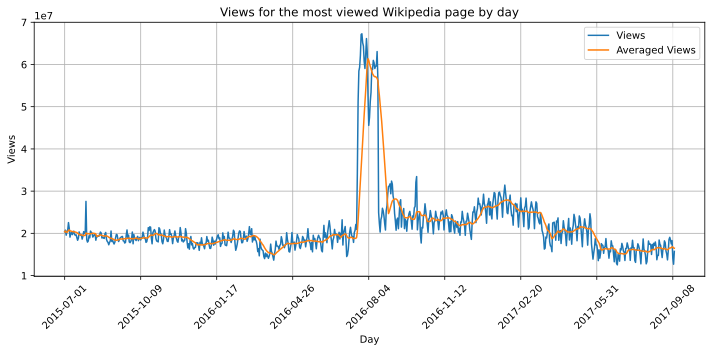

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

### 2.5 YOUR CODE HERE:
...

fig.tight_layout()
plt.show()

**Task 2.6:** Using information from the `articles` DataFrame, calculate the maximum number of views for all preceding days for each record grouped by Project/Access.

In [ ]:
### 2.6 YOUR CODE HERE:
...
stats_df = ...
stats_df.show(10, truncate=False)
stats = stats_df.toPandas()

+-----------------+-------+----------+---------+
|Project          |Access |Day       |Max Views|
+-----------------+-------+----------+---------+
|www.mediawiki.org|desktop|2015-07-01|30476    |
|www.mediawiki.org|desktop|2015-07-02|36043    |
|www.mediawiki.org|desktop|2015-07-03|36043    |
|www.mediawiki.org|desktop|2015-07-04|36043    |
|www.mediawiki.org|desktop|2015-07-05|36043    |
|www.mediawiki.org|desktop|2015-07-06|36043    |
|www.mediawiki.org|desktop|2015-07-07|39979    |
|www.mediawiki.org|desktop|2015-07-08|39979    |
|www.mediawiki.org|desktop|2015-07-09|39979    |
|www.mediawiki.org|desktop|2015-07-10|48142    |
+-----------------+-------+----------+---------+
only showing top 10 rows



**Task 2.7:** Plot the dynamics of the maximum number of views for preceding days grouped by Project/Access.

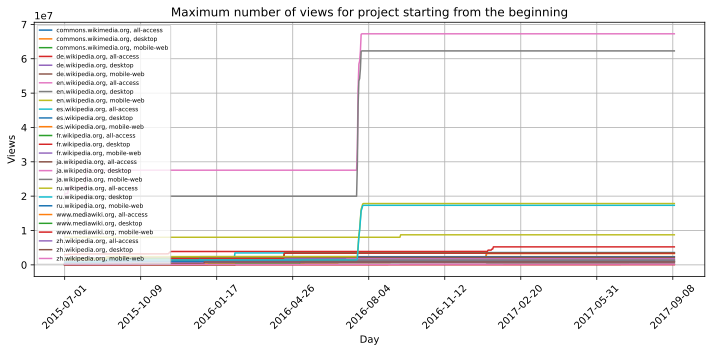

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

### 2.7 YOUR CODE HERE:
...

fig.tight_layout()
plt.show()

**Task 2.8:** Consider the task of predicting the number of views of a specific page for the next day. Consider two simplest prediction variants:
* Average of the $7$ previous days
* Lag with a step of $1$ — value for the previous day

Create two columns that will contain the specified variants of view count prediction.

*Note:* If the prediction is undefined, use the average number of page views.

*Hint:* Functions `cast`, `coalesce` may be useful.

In [ ]:
### 2.8 YOUR CODE HERE:
...
unpivot_with_predictions_df = ...
unpivot_with_predictions_df.show(10)

+--------------------+----------+-----+------------------+------------------+------------------+
|                Page|       Day|Views|        Mean Views|   Mean Prediction|    Lag Prediction|
+--------------------+----------+-----+------------------+------------------+------------------+
|17._November_de.w...|2015-07-01|   30|              30.0|117.36363636363636|117.36363636363636|
|17._November_de.w...|2015-07-02|   35|              32.5|              30.0|              30.0|
|17._November_de.w...|2015-07-03|   31|              32.0|              32.5|              35.0|
|17._November_de.w...|2015-07-04|   20|              29.0|              32.0|              31.0|
|17._November_de.w...|2015-07-05|   25|              28.2|              29.0|              20.0|
|17._November_de.w...|2015-07-06|   38|29.833333333333332|              28.2|              25.0|
|17._November_de.w...|2015-07-07|   40|31.285714285714285|29.833333333333332|              38.0|
|17._November_de.w...|2015-07-

**Task 2.9:** Let's evaluate the resulting models. To do this, we calculate the **SMAPE** metric:

$$
\text{SMAPE} = \frac{200\%}{n} \sum\limits_{i=1}^{n} \frac{|y_{i} - \hat{y}_{i}|}{|y_{i}| + |\hat{y}_{i}|}
$$

Where $y_{i}$, $\hat{y}_{i}$ are the true answer (target) and the model prediction, respectively.

You can read more about [SMAPE](https://en.wikipedia.org/wiki/Symmetric_mean_absolute_percentage_error) and [MAPE](https://en.wikipedia.org/wiki/Mean_absolute_percentage_error) on Wikipedia, as well as in [A.G. Dyakonov's book](https://alexanderdyakonov.files.wordpress.com/2018/10/book_08_metrics_12_blog1.pdf).

For convenience, we will implement the metric calculation as a separate function.

In [ ]:
def count_smape(
    df: pyspark.sql.dataframe.DataFrame, 
    target_col: str, prediction_col: str,
    groups: Optional[List[str]]=None
) -> pyspark.sql.dataframe.DataFrame:
    '''
     :param pyspark.sql.dataframe.DataFrame df: Dataframe for which SMAPE is calculated
     :param str target_col: Name of the column containing true target values
     :param str prediction_col: Name of the column containing predictions
     :param Optional[List[str]] groups: List of columns by which to aggregate metric values
         for individual sample objects. If `groups is None`, return the average for the entire sample
     :return pyspark.sql.dataframe.DataFrame: 
    '''
    ### YOUR CODE HERE:
    ...
    
    if groups is None:
        ### YOUR CODE HERE:
        return ...
    else:
        ### YOUR CODE HERE:
        return ...

In [32]:
count_smape(unpivot_with_predictions_df, 'Views', 'Lag Prediction').show()
count_smape(unpivot_with_predictions_df, 'Views', 'Mean Prediction').show()

+-----------------+
|            SMAPE|
+-----------------+
|36.17647072185545|
+-----------------+

+-----------------+
|            SMAPE|
+-----------------+
|36.81491846337296|
+-----------------+



In [33]:
count_smape(
    unpivot_with_predictions_df.join(articles, on='Page', how='inner'), 
    'Views', 'Lag Prediction', groups=['Project']
).show(10, truncate=False)
count_smape(
    unpivot_with_predictions_df.join(articles, on='Page', how='inner'), 
    'Views', 'Mean Prediction', groups=['Project']
).show(10, truncate=False)

+---------------------+------------------+
|Project              |SMAPE             |
+---------------------+------------------+
|commons.wikimedia.org|59.6298498614523  |
|en.wikipedia.org     |32.63956020407227 |
|www.mediawiki.org    |62.258139736306596|
|de.wikipedia.org     |37.319961625581655|
|es.wikipedia.org     |32.86101430289916 |
|ja.wikipedia.org     |32.03821442890808 |
|ru.wikipedia.org     |26.811208160514123|
|zh.wikipedia.org     |33.59862386011561 |
|fr.wikipedia.org     |36.592989194753194|
+---------------------+------------------+



+---------------------+------------------+
|Project              |SMAPE             |
+---------------------+------------------+
|commons.wikimedia.org|63.557871053100186|
|en.wikipedia.org     |32.99681011925371 |
|www.mediawiki.org    |59.3623870211388  |
|de.wikipedia.org     |36.822607901766446|
|es.wikipedia.org     |33.61237523176791 |
|ja.wikipedia.org     |33.984040552171976|
|ru.wikipedia.org     |27.92595060910766 |
|zh.wikipedia.org     |33.1297890217529  |
|fr.wikipedia.org     |35.91425429634095 |
+---------------------+------------------+



**Task 2.10:** Determine which of the two models works better. Is the result the same for different Projects? And for Action/Access?

In [34]:
### 2.10 YOUR CODE HERE:
...

**Answer:** Your answer here.

### `Part 3. Spark EDA + ML`

<span style="color:red"><b>Using the `pandas` and `sklearn` libraries is prohibited. Transferring the Spark DataFrame to the driver with the dataset is prohibited.</b></span>

#### `3.1. Loading and reading data`

Download and unzip data from the [Mobile Price Classification](https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification) competition.

In [35]:
path = './mobile-price-classification'

! kaggle datasets download -d iabhishekofficial/mobile-price-classification
! unzip -o mobile-price-classification.zip -d $path
! rm -rf mobile-price-classification.zip

Dataset URL: https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification
License(s): unknown
  0%|                                               | 0.00/70.6k [00:00<?, ?B/s]
100%|██████████████████████████████████████| 70.6k/70.6k [00:00<00:00, 26.2MB/s]
Archive:  mobile-price-classification.zip
  inflating: ./mobile-price-classification/test.csv  
  inflating: ./mobile-price-classification/train.csv  


**Task 3.1:** Specify data source and create `pyspark.DataFrame` `df_train, df_test` with training and test data:

In [ ]:
# 3.1 YOUR CODE HERE:
df_test = ...
df_train = ...

**Task 3.2:** Check that `df_train, df_test` loaded correctly. Output the first $10$ rows of the `DataFrame`.

In [ ]:
# 3.2 YOUR CODE HERE:
...

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,381,1018,3220,13,8,18,1,0,1,3
7,1954,0,0.5,1,0,0,24,0.8,187,4,...,512,1149,700,16,3,5,1,1,1,0
8,1445,1,0.5,0,0,0,53,0.7,174,7,...,386,836,1099,17,1,20,1,0,0,0
9,509,1,0.6,1,2,1,9,0.1,93,5,...,1137,1224,513,19,10,12,1,0,0,0


In [ ]:
# 3.2 YOUR CODE HERE:
...

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1
5,6,1464,1,2.9,1,5,1,50,0.8,198,...,9,569,939,3506,10,7,3,1,1,1
6,7,1718,0,2.4,0,1,0,47,1.0,156,...,3,1283,1374,3873,14,2,10,0,0,0
7,8,833,0,2.4,1,0,0,62,0.8,111,...,2,1312,1880,1495,7,2,18,0,1,1
8,9,1111,1,2.9,1,9,1,25,0.6,101,...,19,556,876,3485,11,9,10,1,1,0
9,10,1520,0,0.5,0,1,0,25,0.5,171,...,20,52,1009,651,6,0,5,1,0,1


**Task 3.3:** Output the column names and their types:

In [ ]:
# 3.3 YOUR CODE HERE:
...

root
 |-- battery_power: integer (nullable = true)
 |-- blue: integer (nullable = true)
 |-- clock_speed: double (nullable = true)
 |-- dual_sim: integer (nullable = true)
 |-- fc: integer (nullable = true)
 |-- four_g: integer (nullable = true)
 |-- int_memory: integer (nullable = true)
 |-- m_dep: double (nullable = true)
 |-- mobile_wt: integer (nullable = true)
 |-- n_cores: integer (nullable = true)
 |-- pc: integer (nullable = true)
 |-- px_height: integer (nullable = true)
 |-- px_width: integer (nullable = true)
 |-- ram: integer (nullable = true)
 |-- sc_h: integer (nullable = true)
 |-- sc_w: integer (nullable = true)
 |-- talk_time: integer (nullable = true)
 |-- three_g: integer (nullable = true)
 |-- touch_screen: integer (nullable = true)
 |-- wifi: integer (nullable = true)
 |-- price_range: integer (nullable = true)



**Task 3.4:** Look at basic sample statistics by columns:

In [ ]:
# 3.4 YOUR CODE HERE:
...

,summary,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,count,2000,2000,2000,2000,2000,2000,2000,2000,2000,...,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
1,mean,1238.5185,0.495,1.5222499999999983,0.5095,4.3095,0.5215,32.0465,0.5017500000000017,140.249,...,645.108,1251.5155,2124.213,12.3065,5.767,11.011,0.7615,0.503,0.507,1.5
2,stddev,439.4182060835313,0.5001000400170073,0.816004208895068,0.5000347661750049,4.341443747983898,0.49966246736236364,18.145714955206856,0.2884155496235117,35.39965489638834,...,443.78081080643824,432.1994469463379,1084.7320436099492,4.213245004356303,4.356397605826408,5.463955197766688,0.426272922318731,0.5001160445626741,0.5000760322381088,1.1183136021064597
3,min,501,0,0.5,0,0,0,2,0.1,80,...,0,500,256,5,0,2,0,0,0,0
4,25%,851,0,0.7,0,1,0,16,0.2,109,...,282,874,1206,9,2,6,1,0,0,0
5,50%,1225,0,1.5,1,3,1,32,0.5,141,...,564,1247,2146,12,5,11,1,1,1,1
6,75%,1615,1,2.2,1,7,1,48,0.8,170,...,947,1633,3064,16,9,16,1,1,1,2
7,max,1998,1,3.0,1,19,1,64,1.0,200,...,1960,1998,3998,19,18,20,1,1,1,3


#### `3.2. EDA and Visualization`

Let's visualize different statistics.

Analyze missing values in the data. Suppose we can transfer data to the driver, then we can visualize missing values via the `Axes.spy` method:

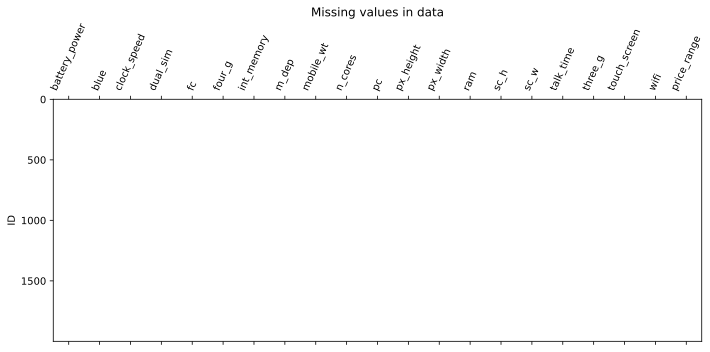

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

df_train_pd = df_train.toPandas()
ax.spy(df_train_pd.isnull(), precision=0.0, aspect='auto')

ax.set_xticks(np.arange(len(df_train_pd.columns)), labels=df_train_pd.columns, rotation=66)
ax.set_ylabel('ID')
ax.grid(False)

ax.set_title('Missing values in data')

fig.tight_layout()
plt.show()

What if we want to perform visualization without transferring all data to the driver? A logical solution is to calculate statistics efficiently and transfer only a small amount of data to the driver.

**Task 3.5:** The [`.spy`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.spy.html) method can work with sparse matrices. We can assume that there are few missing values, so they can be explicitly transferred to the driver in coordinate form (each missing value is defined by a pair of row number, column number).

Use the RDD API to extract the coordinate representation of missing values from the DataFrame. Then create a sparse matrix from these coordinates and plot it.

Useful methods: `zipWithIndex`, `flatMap`.

In [42]:
from scipy.sparse import csr_matrix

def get_value_indices(row, idx, target_value):
    result = []
    for jdx, value in enumerate(row):
        if value == target_value:
            result.append((idx, jdx))
    return result

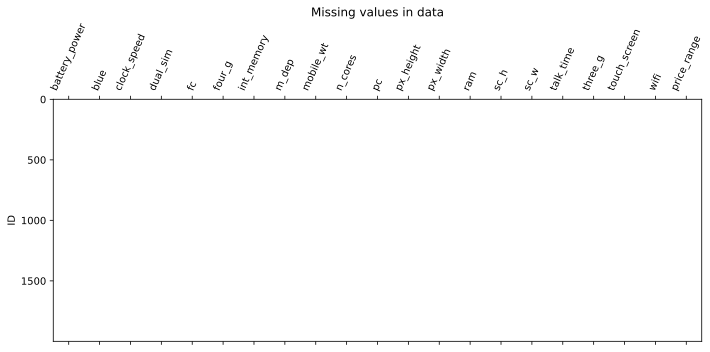

In [ ]:
# 3.5 YOUR CODE HERE:
none_indices = ...
if len(none_indices):
    row_idxs, col_idxs = list(zip(*none_indices))
else:
    row_idxs, col_idxs = [], []

matrix = ...

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.spy(matrix, precision='present', aspect='auto', markersize=0.1)

ax.set_xticks(np.arange(len(df_train.columns)), labels=df_train.columns, rotation=66)
ax.set_ylabel('ID')
ax.grid(False)

ax.set_title('Missing values in data')

fig.tight_layout()
plt.show()

There are no missing values in the data. Let's look at zero values in the data for interest.

**Task 3.6:** Output the location of zero values in the dataset:

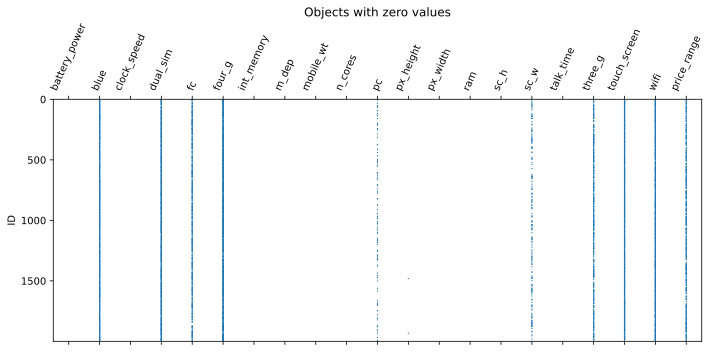

In [ ]:
# 3.6 YOUR CODE HERE:
zero_indices = ...
if len(zero_indices):
    row_idxs, col_idxs = list(zip(*zero_indices))
else:
    row_idxs, col_idxs = [], []

matrix = ...

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.spy(matrix, precision='present', aspect='auto', markersize=0.1)

ax.set_xticks(np.arange(len(df_train.columns)), labels=df_train.columns, rotation=66)
ax.set_ylabel('ID')
ax.grid(False)

ax.set_title('Objects with zero values')

fig.tight_layout()
plt.show()

**Task 3.7:** Calculate and plot pairwise column correlations:

In the cell below, you can use `pandas` to create a DataFrame from the calculated correlations.

Useful modules: `pyspark.ml.stat`, `pyspark.ml.feature`.

In [ ]:
# 3.7 YOUR CODE HERE:
...

correlations = ...
correlations

25/11/30 23:57:39 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/11/30 23:57:39 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


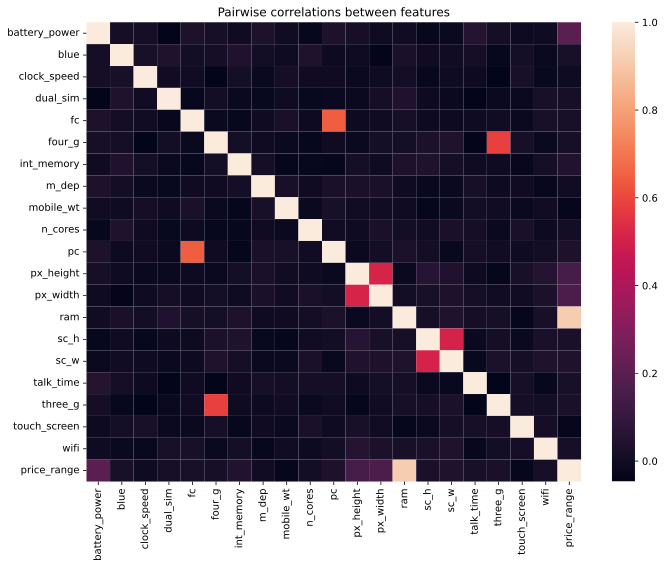

In [ ]:
# 3.7 YOUR CODE HERE:
...

**Task 3.8:** See what classes are present in this classification task and their frequency of occurrence:

In [ ]:
# 3.8 YOUR CODE HERE:
...

,price_range,count
0,1,500
1,3,500
2,2,500
3,0,500


The classes are balanced in this task.

Let's study the distributions of variables depending on the target.

**Task 3.9:** For each variable (column), plot its distribution grouped by class:

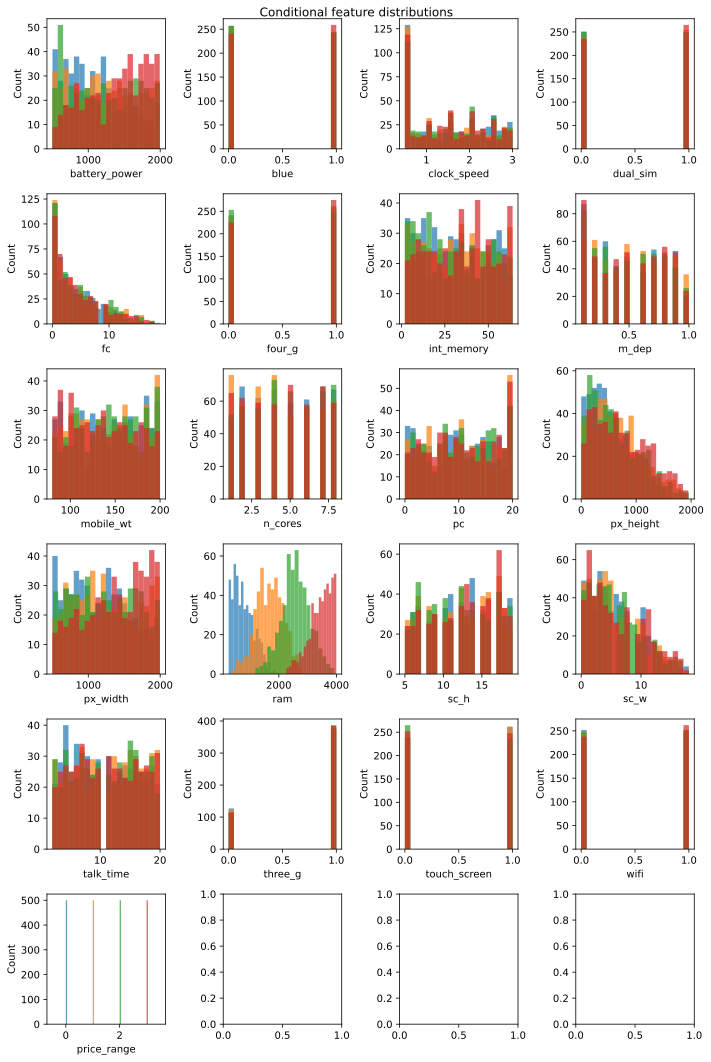

In [ ]:
# 3.9 YOUR CODE HERE:
...

Let's look at other conditional distributions in the form of their statistics.

`boxplot` is often used to visualize distributions:

`boxplot` is defined by the following set of statistics:
 1. Quantiles Q1, median, Q3
 2. Lower and upper outlier boundaries (Q1 - 1.5IQR / Q3 + 1.5IQR, but not less/more than the minimum/maximum of the sample)
 3. Outliers
 
 To draw a `boxplot` using these statistics, you can use the [`.bxp`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bxp.html) method.
 
 Implement the helper function `draw_boxplot`. This function takes a Spark DataFrame, the name of the column for grouping data `x`, the name of the column with data `y`, and the axes for drawing `ax`. The function groups the data, calculates the specified statistics in each group, and then draws a set of boxplots based on them.

Box and Whisker Plot:
```txt
    Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                  |-----:-----|
  o      |--------|     :     |--------|    o  o
                  |-----:-----|
flier             <----------->            fliers
                       IQR
```

**Task 3.10:** For each variable (column), plot a `boxplot` grouped by class:

In [ ]:
def draw_boxplot(df, x, y, ax):
    # 3.10 YOUR CODE HERE:
    ...
    
    # 3.10 YOUR CODE HERE:
    boxes = ax.bxp(...)['boxes']
    for box in boxes:
        ax.fill(box.get_xdata(), box.get_ydata())
        
    # 3.10 YOUR CODE HERE:
    ...

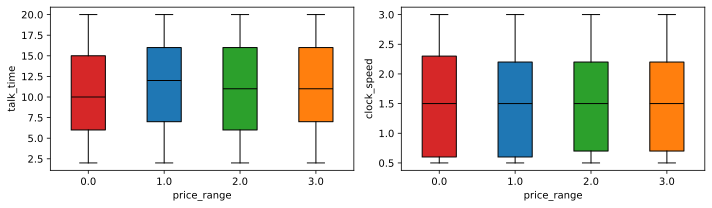

In [50]:
# 3.10 YOUR CODE HERE:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

draw_boxplot(df_train, x='price_range', y='talk_time', ax=axes[0])
draw_boxplot(df_train, x='price_range', y='clock_speed', ax=axes[1])

fig.tight_layout()
plt.show()

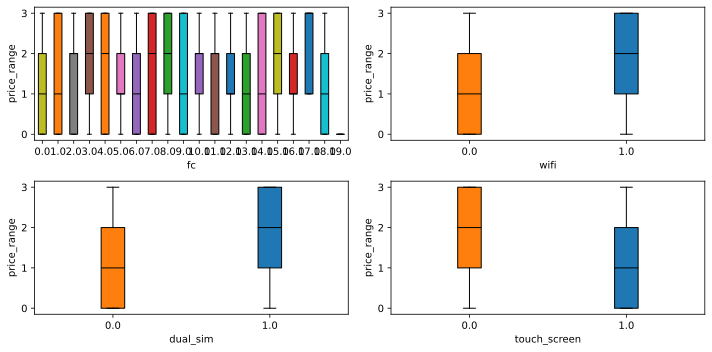

In [51]:
# 3.10 YOUR CODE HERE:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))

draw_boxplot(df_train, x='fc', y='price_range', ax=axes[0, 0])
draw_boxplot(df_train, x='wifi', y='price_range', ax=axes[0, 1])
draw_boxplot(df_train, x='dual_sim', y='price_range', ax=axes[1, 0])
draw_boxplot(df_train, x='touch_screen', y='price_range', ax=axes[1, 1])

fig.tight_layout()
plt.show()

**Task 3.11:** Analyze the network capabilities of the phones. Output how many phones support 3G/4G and how many do not:

In [ ]:
# 3.11 YOUR CODE HERE:
...
three_g_values, four_g_values

(   three_g  count
 0        1   1523
 1        0    477,
    four_g  count
 0       1   1043
 1       0    957)

**Task 3.12:** Visualize these statistics as a pie chart:

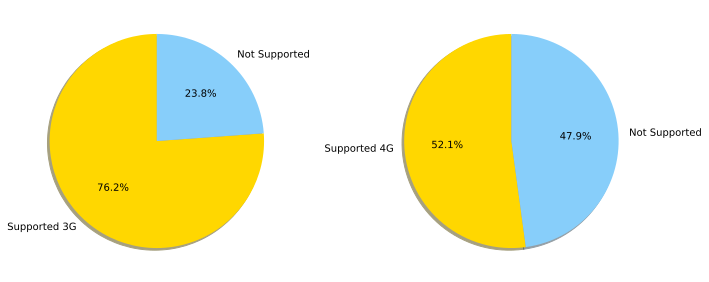

In [ ]:
# 3.12 YOUR CODE HERE:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

...

fig.tight_layout()
plt.show()

**Task 3.13:** Let's look at camera quality information. Output the quality distribution of the primary and front cameras:

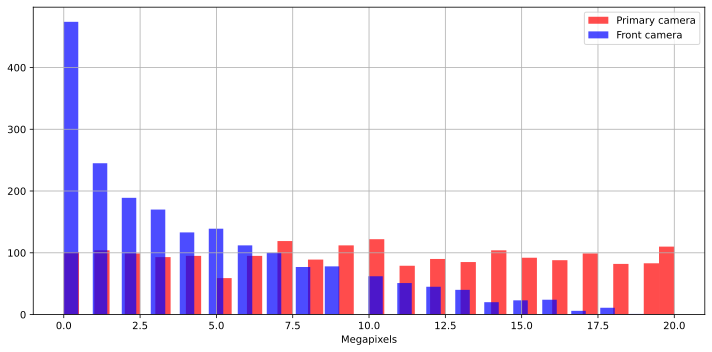

In [ ]:
# 3.13 YOUR CODE HERE:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

...

fig.tight_layout()
plt.show()

#### `3.3. Training models and evaluating quality`

In [55]:
from pyspark.ml import Pipeline

from pyspark.ml.feature import VectorAssembler, StandardScaler

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier

from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

Prepare the data for training. 

**Task 3.14:** Split `df_train` into training and validation sets:

In [ ]:
# 3.14 YOUR CODE HERE:
Xy_train, Xy_test = ...

**Task 3.15:** Perform feature scaling and train a base model — Logistic Regression:

In [ ]:
# 3.15 YOUR CODE HERE:
...

**Task 3.15:** Make predictions on the training and validation sets:

In [ ]:
# 3.15 YOUR CODE HERE:
y_train_lr_pred = ...
y_test_lr_pred = ...

**Task 3.16:** Calculate Accuracy, look at Confusion Matrix and Classification Report:

You can use [MulticlassMetrics](https://spark.apache.org/docs/latest/api/python/reference/api/pyspark.mllib.evaluation.MulticlassMetrics.html) to calculate metrics via the RDD API.

In [ ]:
# 3.16 YOUR CODE HERE:
...

/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Accuracy (Train/Test): 100.0%/96.8%

Confusion Matrix
[[163.   4.   0.   0.]
 [  2. 126.   3.   0.]
 [  0.   4. 146.   6.]
 [  0.   0.   0. 140.]]

Classification Report
   precision    recall  f1-score  support
0   0.987879  0.976048  0.981928    131.0
1   0.940299  0.961832  0.950943    140.0
2   0.979866  0.935897  0.957377    156.0
3   0.958904  1.000000  0.979021    167.0


**Task 3.17:** Now train another algorithm — Random Forest. Immediately perform hyperparameter tuning with cross-validation:

In [ ]:
numFolds = 3
n_estimators = 200
max_depth_range = [1, 2, 3, 5, 8]
subsampling_rate_range = [0.1, 0.3, 0.7, 0.9]

# 3.17 YOUR CODE HERE:
...

25/11/30 23:58:01 WARN DAGScheduler: Broadcasting large task binary with size 1070.5 KiB
25/11/30 23:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1107.6 KiB
25/11/30 23:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1330.6 KiB
25/11/30 23:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1331.9 KiB
25/11/30 23:58:02 WARN DAGScheduler: Broadcasting large task binary with size 1449.9 KiB
25/11/30 23:58:05 WARN DAGScheduler: Broadcasting large task binary with size 1248.7 KiB
25/11/30 23:58:06 WARN DAGScheduler: Broadcasting large task binary with size 1522.4 KiB
25/11/30 23:58:06 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/11/30 23:58:06 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
25/11/30 23:58:07 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
25/11/30 23:58:09 WARN DAGScheduler: Broadcasting large task binary with size 1060.8 KiB
25/11/30 23:58:09 WARN DAGSche

CrossValidatorModel_6e5d67e10c88

**Task 3.18:** Plot the dependence of accuracy on cross-validation on hyperparameters as a heatmap:

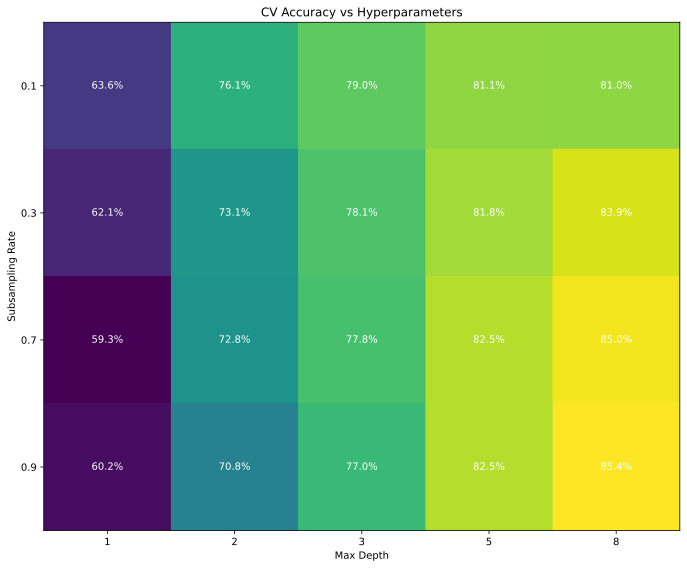

In [ ]:
# 3.18 YOUR CODE HERE:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

...

fig.tight_layout()
plt.show()

**Task 3.19:** Determine which of the hyperparameters are optimal. Train the model with the best parameters and measure its quality on the test set:

In [ ]:
# 3.19 YOUR CODE HERE:
...

/home/maksim64/miniconda3/envs/spark/lib/python3.11/site-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(
25/11/30 23:58:56 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/11/30 23:58:56 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
25/11/30 23:58:56 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB


Accuracy (Train/Test): 98.7%/86.4%

Confusion Matrix
[[156.  11.   0.   0.]
 [  3. 120.   8.   0.]
 [  0.  26. 110.  20.]
 [  0.   0.  13. 127.]]

Classification Report
   precision    recall  f1-score  support
0   0.981132  0.934132  0.957055    131.0
1   0.764331  0.916031  0.833333    140.0
2   0.839695  0.705128  0.766551    156.0
3   0.863946  0.907143  0.885017    167.0


25/11/30 23:58:56 WARN DAGScheduler: Broadcasting large task binary with size 3.9 MiB
